# DRE-GloFAS comparison

In [2]:
%load_ext jupyter_black
%load_ext autoreload
%autoreload 2

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.datasources import dre, glofas

In [4]:
MIN_YEAR = 2003

In [5]:
df_dre = dre.open_dre_obsv()
df_dre = df_dre.rename(columns={"Date": "time"})
df_dre["dayofyear"] = df_dre["time"].dt.dayofyear
df_dre["eff_date"] = pd.to_datetime(df_dre["dayofyear"], format="%j")
df_dre = df_dre[df_dre["time"].dt.year >= MIN_YEAR]
df_dre = df_dre.dropna()
df_dre = df_dre.drop_duplicates()
# df_dre = df_dre.drop_duplicates(keep=False, subset="time")

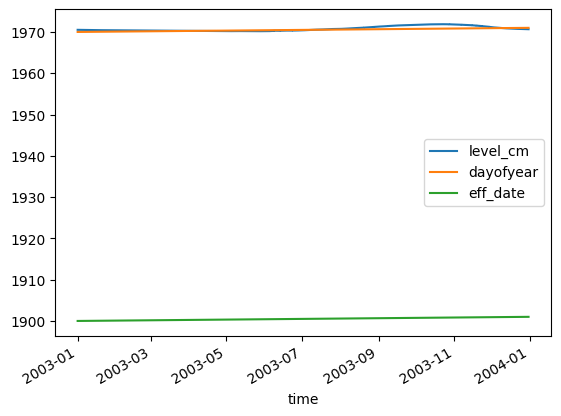

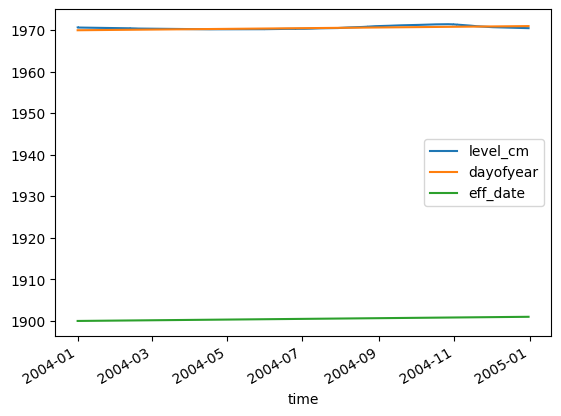

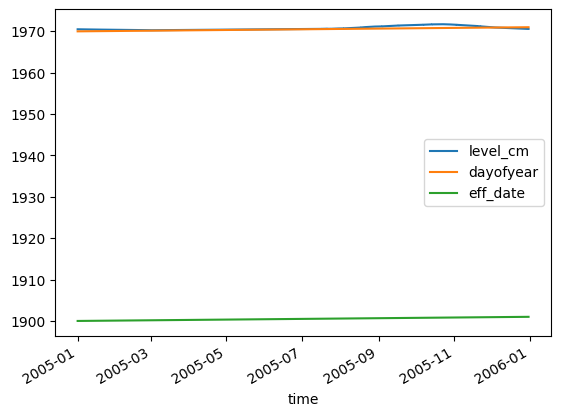

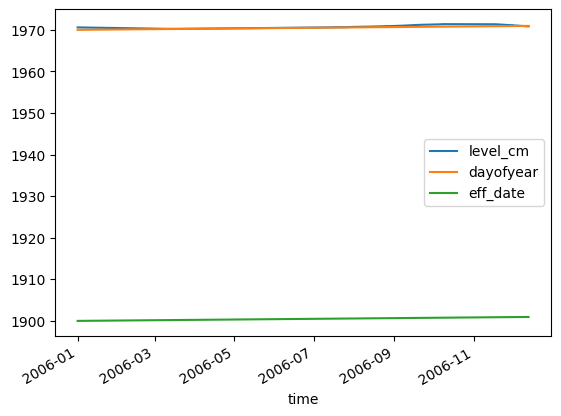

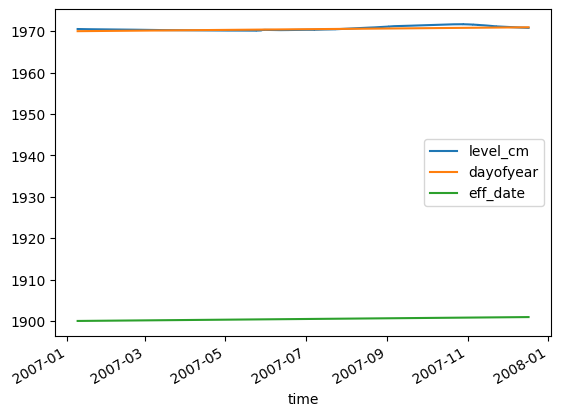

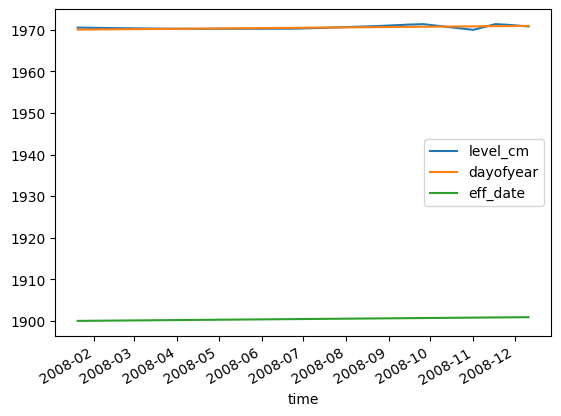

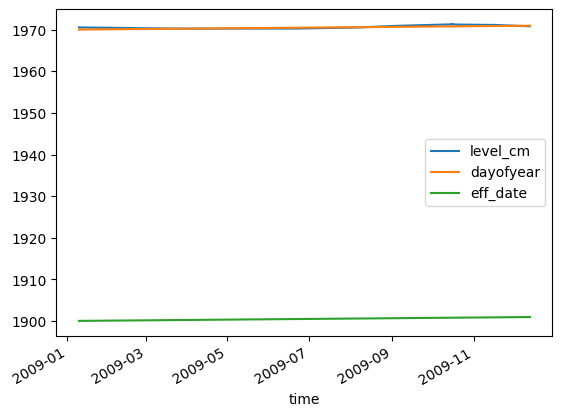

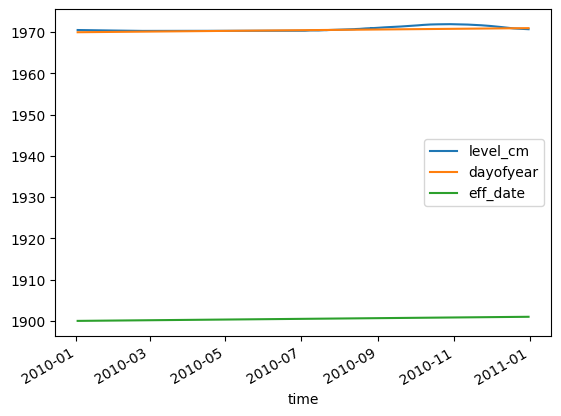

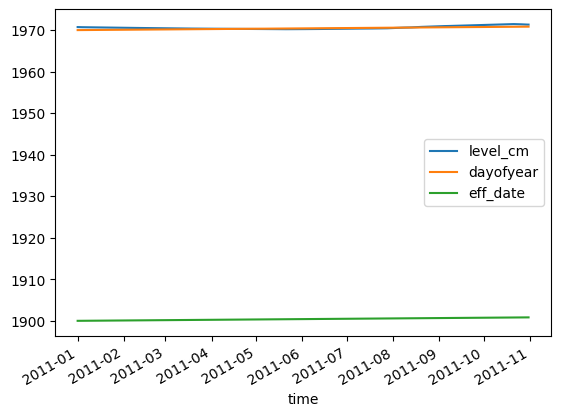

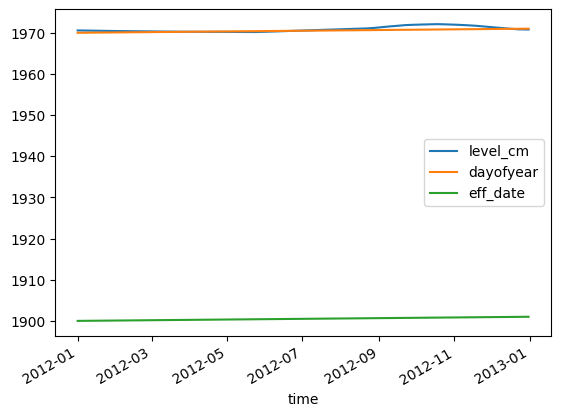

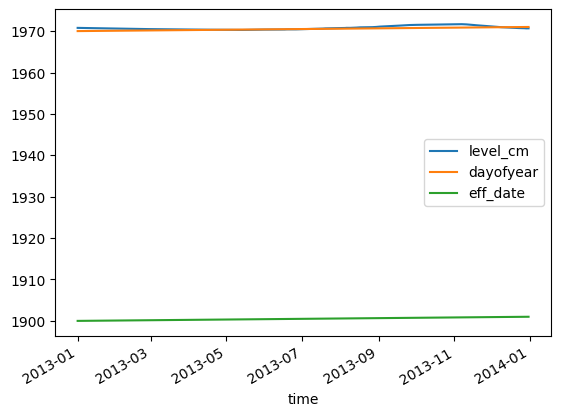

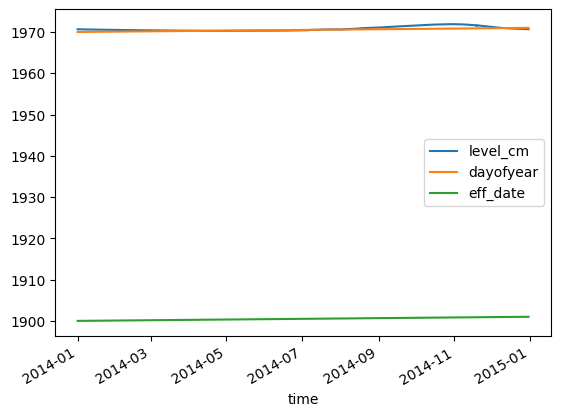

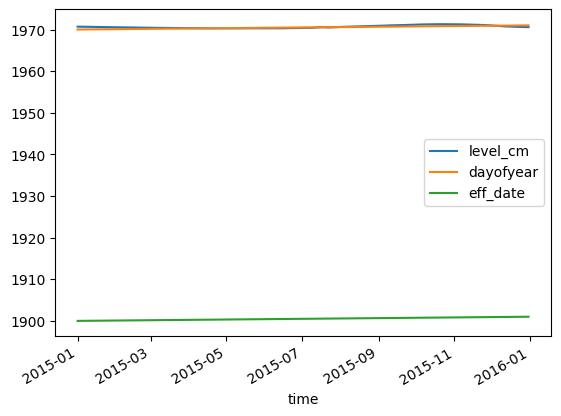

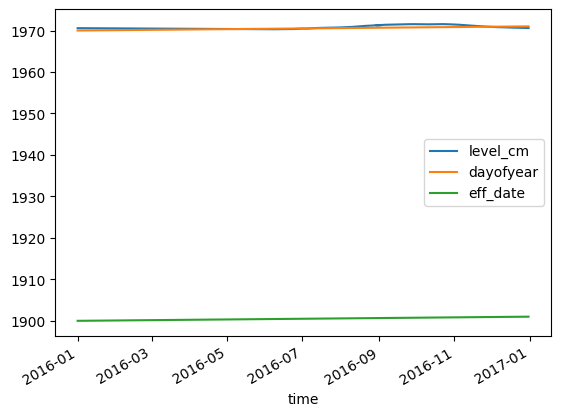

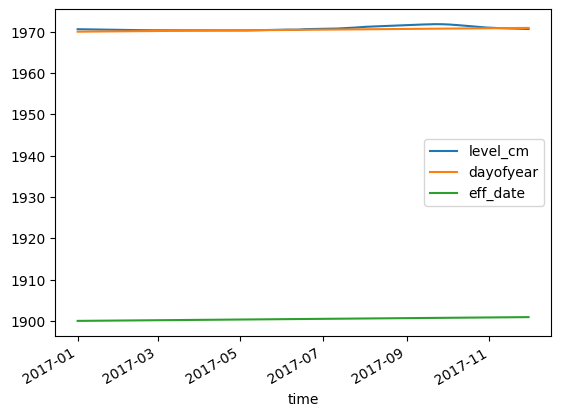

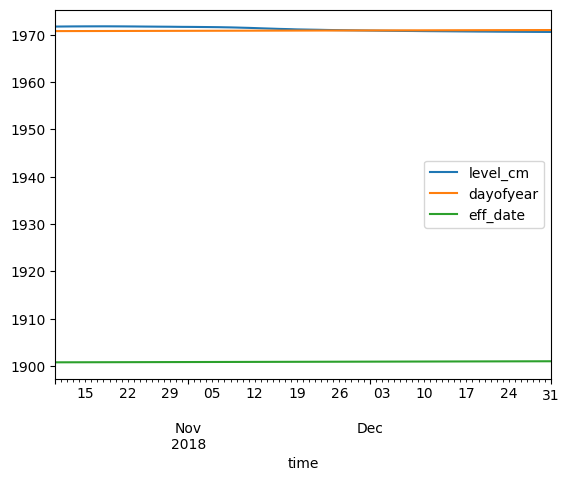

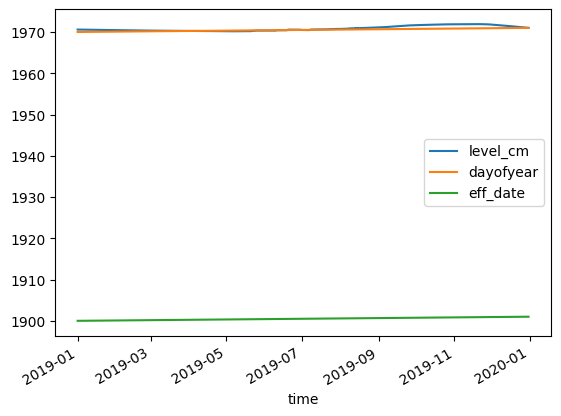

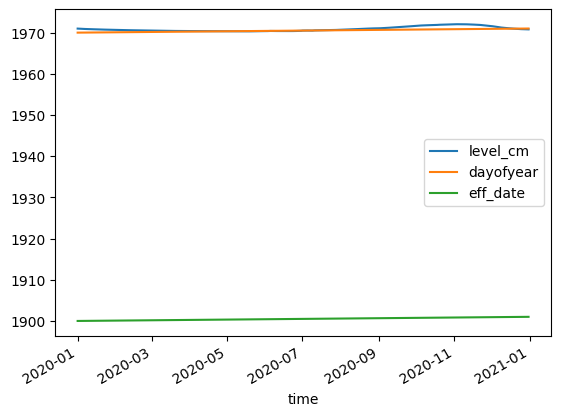

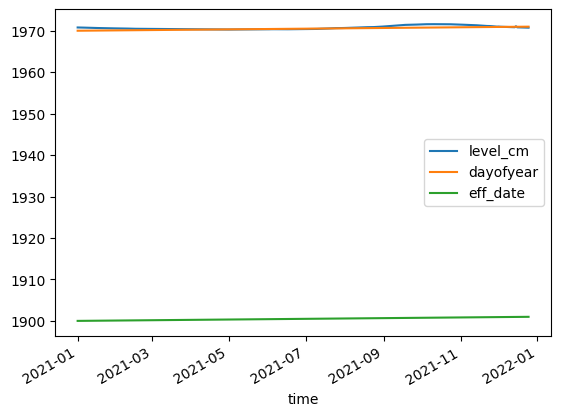

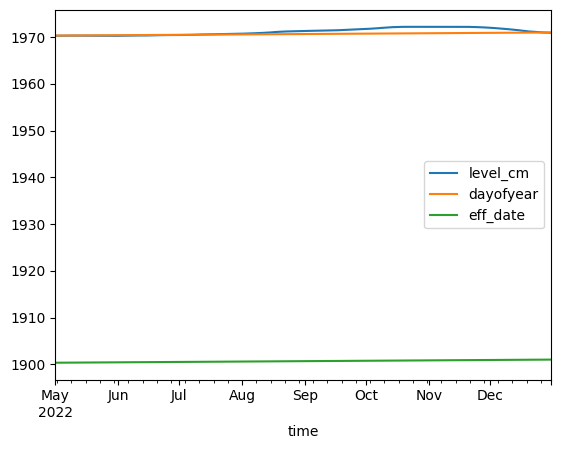

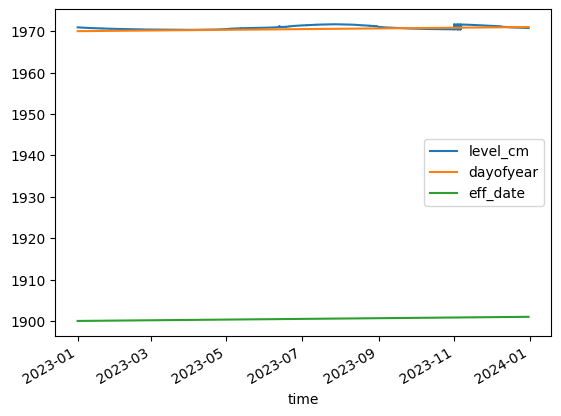

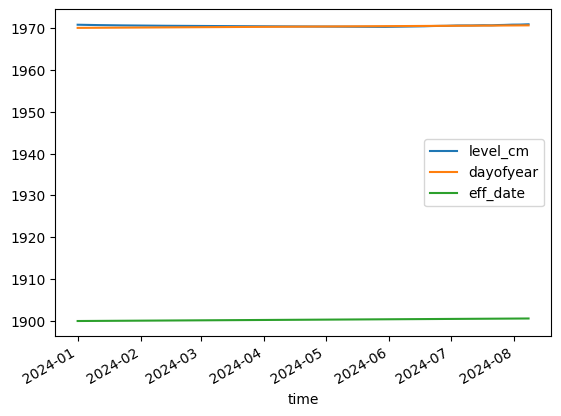

In [6]:
for year in df_dre["time"].dt.year.unique():
    fig, ax = plt.subplots()
    df_dre[df_dre["time"].dt.year == year].set_index("time").plot(ax=ax)
    plt.show()
    plt.close()

In [7]:
DROP_YEARS = [2006, 2008, 2023, 2024]

In [8]:
df_dre = df_dre[~df_dre["time"].dt.year.isin(DROP_YEARS)]

In [9]:
peaks_dre = df_dre.loc[
    df_dre.groupby(df_dre["time"].dt.year)["level_cm"].idxmax()
]
peaks_dre["year"] = peaks_dre["time"].dt.year
peaks_dre["rank"] = peaks_dre["level_cm"].rank(ascending=False)
peaks_dre["rp"] = len(peaks_dre) / peaks_dre["rank"]
peaks_dre = peaks_dre.sort_values("rank")

In [10]:
len(peaks_dre)

18

In [11]:
df_gf = glofas.load_reanalysis()
df_gf["dayofyear"] = df_gf["time"].dt.dayofyear
df_gf["eff_date"] = pd.to_datetime(df_gf["dayofyear"], format="%j")
df_gf = df_gf[~df_gf["time"].dt.year.isin(DROP_YEARS)]

In [12]:
df_gf

,time,dis24,dayofyear,eff_date
0,2003-01-01,351.32812,1,1900-01-01
1,2003-01-02,347.54688,2,1900-01-02
2,2003-01-03,343.89062,3,1900-01-03
3,2003-01-04,340.43750,4,1900-01-04
4,2003-01-05,337.18750,5,1900-01-05
...,...,...,...,...
7300,2022-12-27,191.53906,361,1900-12-27
7301,2022-12-28,187.07812,362,1900-12-28
7302,2022-12-29,182.73438,363,1900-12-29
7303,2022-12-30,178.53125,364,1900-12-30


In [13]:
peaks_gf = df_gf.loc[df_gf.groupby(df_gf["time"].dt.year)["dis24"].idxmax()]
peaks_gf["year"] = peaks_gf["time"].dt.year
peaks_gf["rank"] = peaks_gf["dis24"].rank(ascending=False)
peaks_gf["rp"] = len(peaks_gf) / peaks_gf["rank"]
peaks_gf = peaks_gf.sort_values("rank")

In [14]:
len(peaks_gf)

18

In [30]:
peaks = peaks_gf.merge(peaks_dre, on="year", suffixes=("_gf", "_dre"))
peaks["days_early"] = peaks["dayofyear_dre"] - peaks["dayofyear_gf"]
peaks = peaks.sort_values("rank_dre")

In [31]:
peaks

,time_gf,dis24,dayofyear_gf,eff_date_gf,year,rank_gf,rp_gf,time_dre,level_cm,dayofyear_dre,eff_date_dre,rank_dre,rp_dre,days_early
1,2022-09-26,6254.0547,269,1900-09-26,2022,2.0,9.000000,2022-11-13,814.0,317,1900-11-13,1.0,18.000000,48
3,2012-09-17,5551.9844,261,1900-09-18,2012,4.0,4.500000,2012-10-18,766.0,292,1900-10-19,2.0,9.000000,31
5,2020-09-19,3401.8203,263,1900-09-20,2020,6.0,3.000000,2020-11-02,747.0,307,1900-11-03,3.0,6.000000,44
0,2010-09-20,6714.9453,263,1900-09-20,2010,1.0,18.000000,2010-10-26,717.0,299,1900-10-26,4.0,4.500000,36
8,2019-11-01,2774.6250,305,1900-11-01,2019,9.0,2.000000,2019-11-15,699.0,319,1900-11-15,5.0,3.600000,14
13,2014-09-18,2316.0469,261,1900-09-18,2014,14.0,1.285714,2014-10-30,694.0,303,1900-10-30,6.0,3.000000,42
2,2003-09-15,6072.0000,258,1900-09-15,2003,3.0,6.000000,2003-10-23,685.0,296,1900-10-23,7.0,2.571429,38
15,2017-10-02,1701.5703,275,1900-10-02,2017,16.0,1.125000,2017-09-23,666.0,266,1900-09-23,8.0,2.250000,-9
6,2018-09-13,3318.6250,256,1900-09-13,2018,7.0,2.571429,2018-10-18,652.0,291,1900-10-18,9.0,2.000000,35
4,2005-09-30,4930.1953,273,1900-09-30,2005,5.0,3.600000,2005-10-21,630.0,294,1900-10-21,10.0,1.800000,21


In [32]:
19 / 5

3.8

In [33]:
len(peaks)

18

Text(0.5, 1.0, "Fleuve Chari à N'Djamena\nPics annuels GloFAS vs. observationnel (2003-2022)")

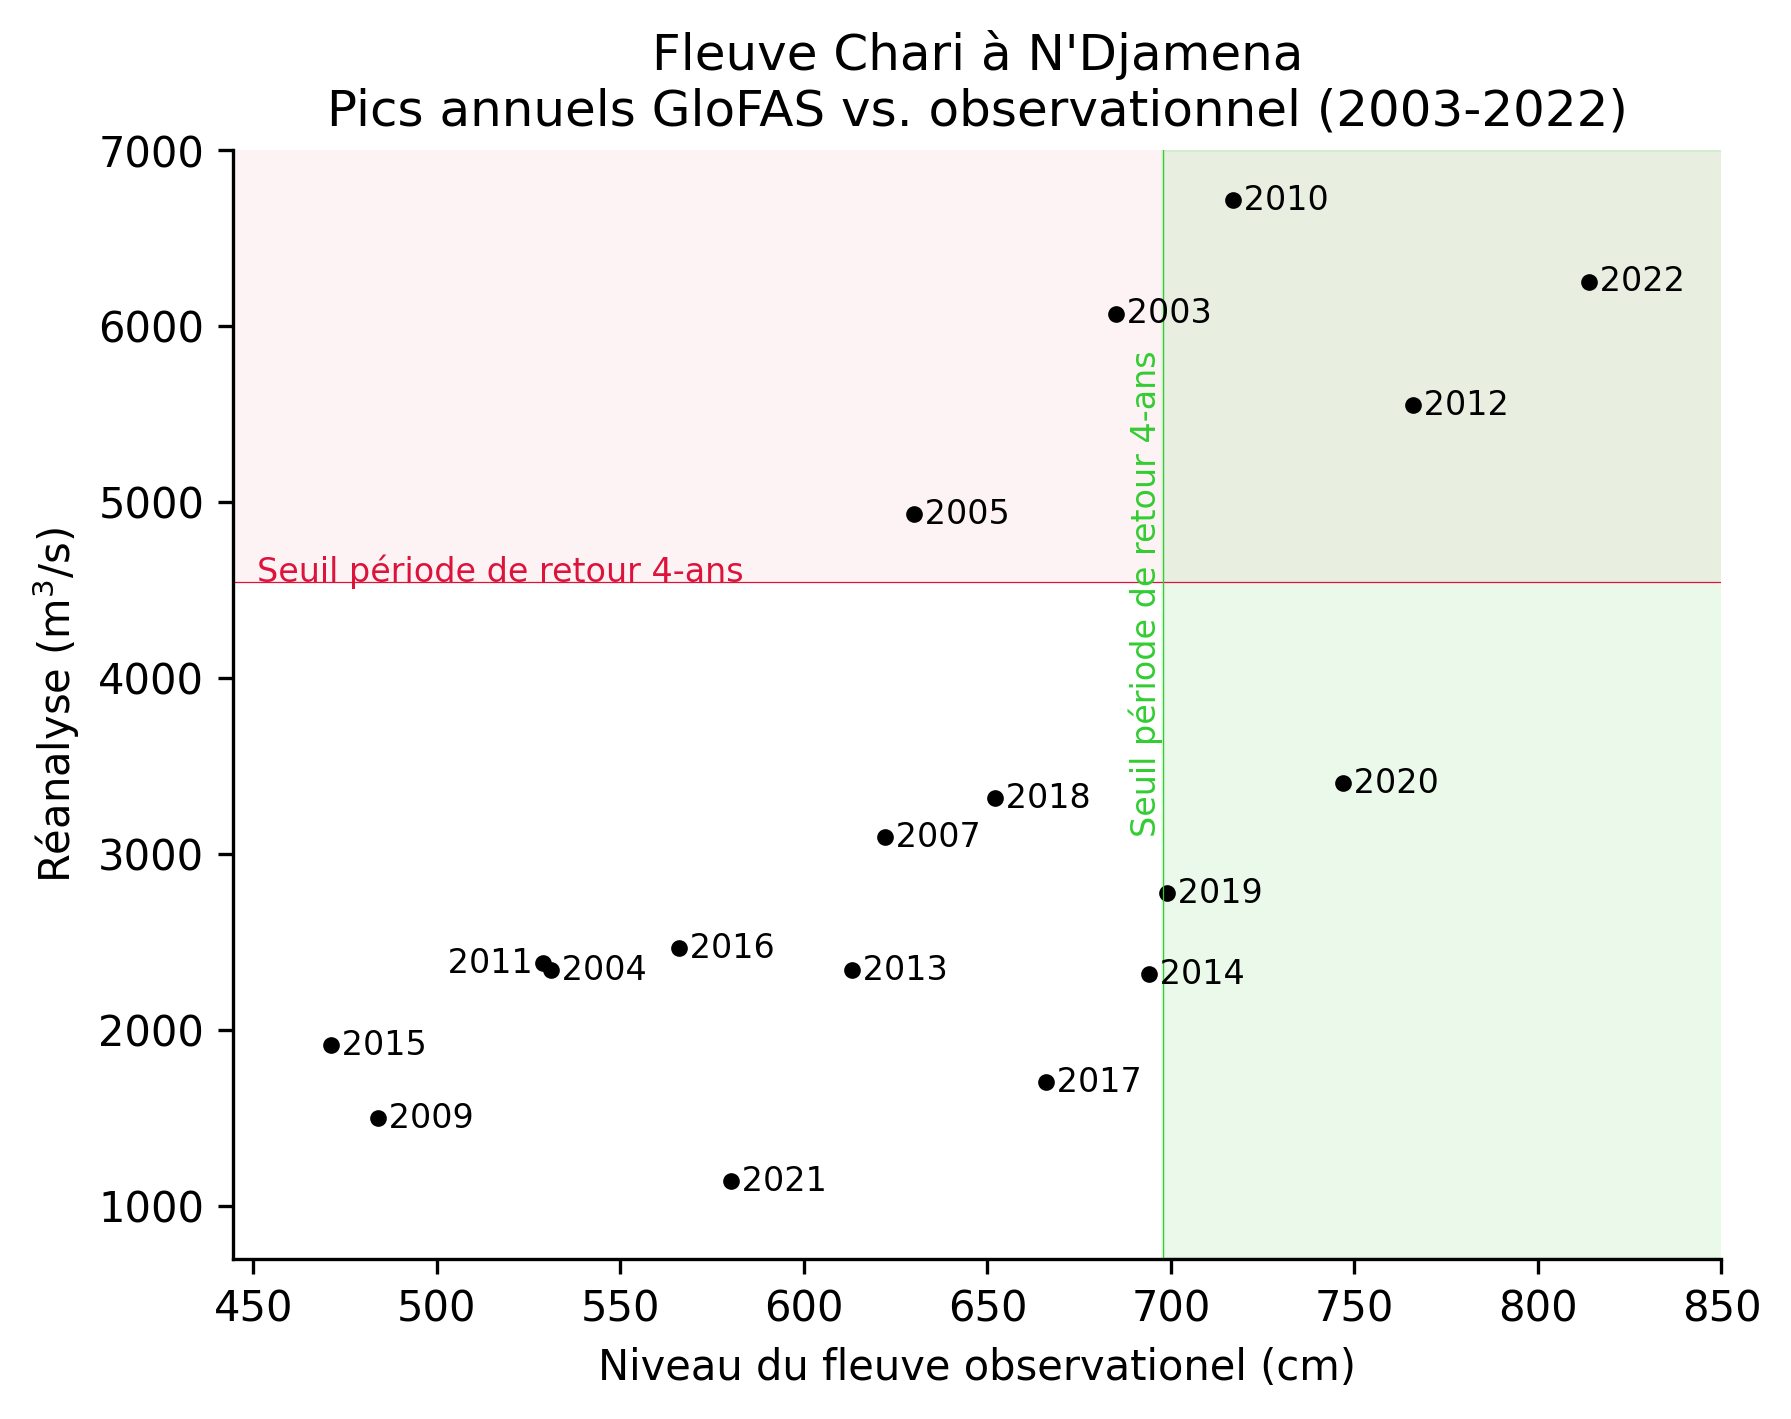

In [34]:
rp = 4

fig, ax = plt.subplots(dpi=300)
peaks.plot(
    x="level_cm",
    y="dis24",
    ax=ax,
    marker=".",
    color="k",
    linestyle="",
    legend=False,
)

ax.axhline(
    y=peaks["dis24"].quantile(1 - 1 / rp),
    color="crimson",
    linestyle="-",
    linewidth=0.3,
)
ax.axhspan(
    peaks["dis24"].quantile(1 - 1 / rp),
    10000,
    color="crimson",
    alpha=0.05,
    linestyle="None",
)
ax.annotate(
    f"Seuil période de retour {rp}-ans",
    (peaks["level_cm"].min() - 20, peaks["dis24"].quantile(1 - 1 / rp)),
    fontsize=8,
    color="crimson",
)
ax.axvline(
    x=peaks["level_cm"].quantile(1 - 1 / rp),
    color="limegreen",
    linestyle="-",
    linewidth=0.3,
)
ax.axvspan(
    peaks["level_cm"].quantile(1 - 1 / rp),
    1000,
    ymin=0,
    ymax=1,
    color="limegreen",
    alpha=0.1,
)
ax.annotate(
    f"Seuil période de retour {rp}-ans",
    (peaks["level_cm"].quantile(1 - 1 / rp), peaks["dis24"].min() + 2000),
    fontsize=8,
    color="limegreen",
    rotation=90,
    ha="right",
)

for year, row in peaks.set_index("year").iterrows():
    flip_years = [2011]
    ha = "right" if year in flip_years else "left"
    ax.annotate(
        f" {year} ",
        (row["level_cm"], row["dis24"]),
        color="k",
        fontsize=8,
        va="center",
        ha=ha,
    )

ax.set_ylim(top=7000)
ax.set_xlim(right=850)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_ylabel("Réanalyse (m$^3$/s)")
ax.set_xlabel("Niveau du fleuve observationel (cm)")
ax.set_title(
    "Fleuve Chari à N'Djamena\nPics annuels GloFAS vs. observationnel (2003-2022)"
)

In [22]:
dre_thresh = peaks["level_cm"].quantile(1 - 1 / 5)
print(f"{dre_thresh=}")
df_dre.loc[
    df_dre[df_dre["level_cm"] >= dre_thresh]
    .groupby(df_dre["time"].dt.year)["time"]
    .idxmin()
]

dre_thresh=709.8000000000001


,time,level_cm,dayofyear,eff_date
42467,2010-10-22,710.0,295,1900-10-22
43625,2012-09-29,711.0,273,1900-09-30
48728,2020-10-22,710.0,296,1900-10-23
49308,2022-10-08,715.0,281,1900-10-08


In [39]:
len(peaks)

18

In [43]:
peaks = peaks.sort_values("rp_dre")
np.interp(750, peaks["level_cm"], peaks["rp_dre"]) * (len(peaks) + 1) / len(
    peaks
)

6.833333333333333

<Axes: xlabel='time'>

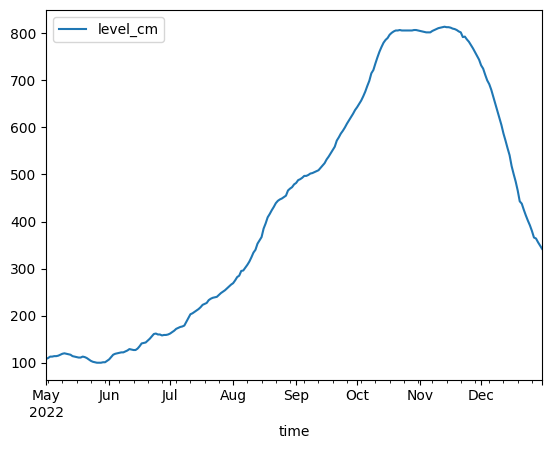

In [23]:
df_dre[df_dre["time"].dt.year == 2022].plot(x="time", y="level_cm")

Text(0.5, 0, 'Observational yearly peak (cm)')

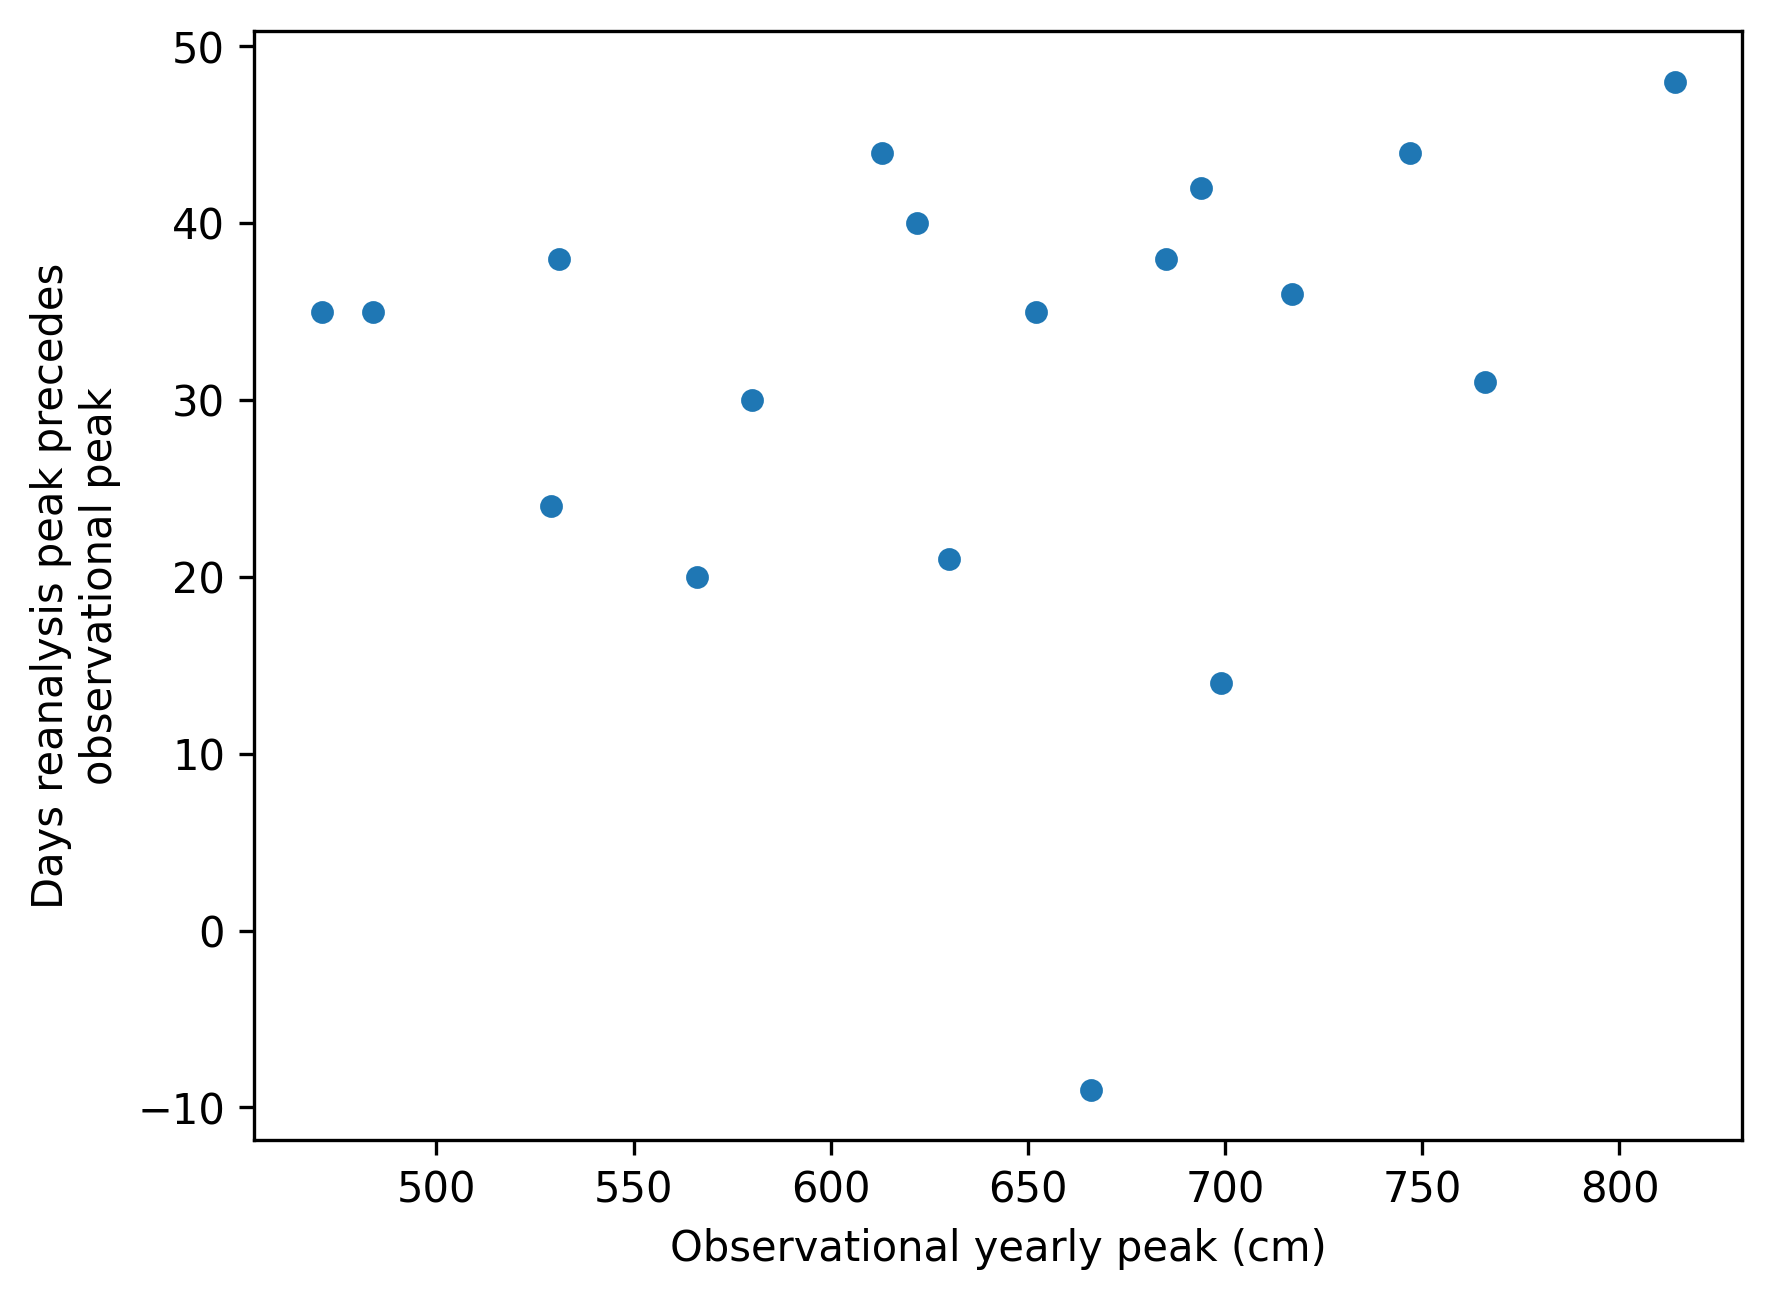

In [18]:
fig, ax = plt.subplots(dpi=300)
peaks.plot.scatter(x="level_cm", y="days_early", ax=ax)
ax.set_ylabel("Days reanalysis peak precedes\nobservational peak")
ax.set_xlabel("Observational yearly peak (cm)")

In [21]:
peaks["days_early"].mean()

31.444444444444443

In [232]:
df = df_gf.merge(df_dre)

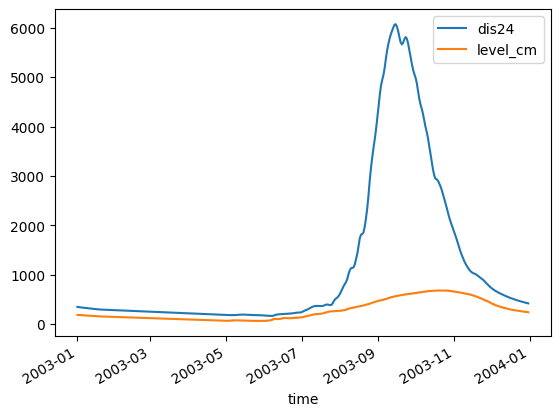

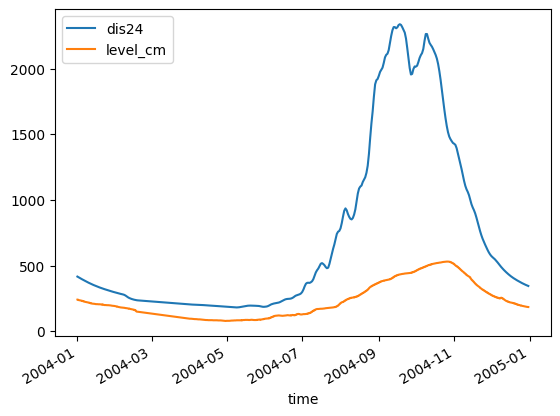

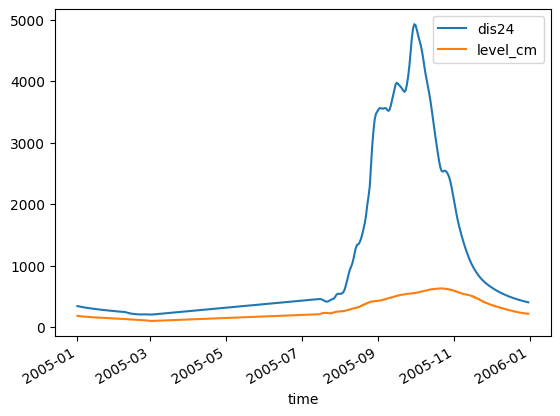

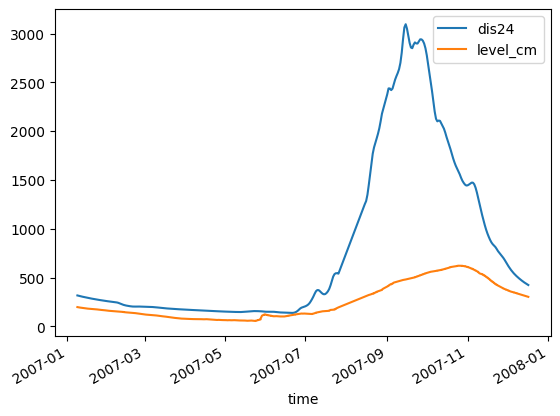

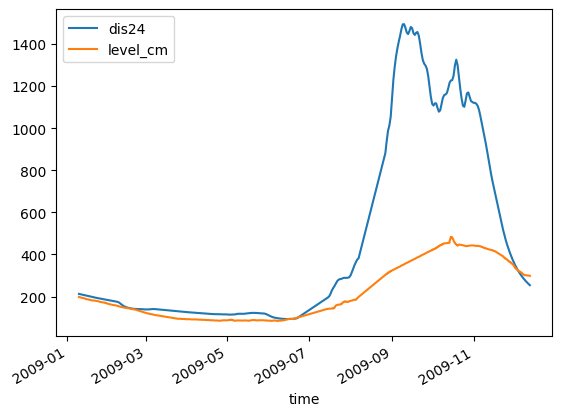

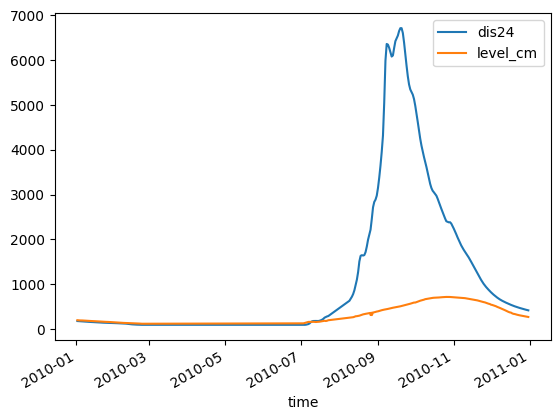

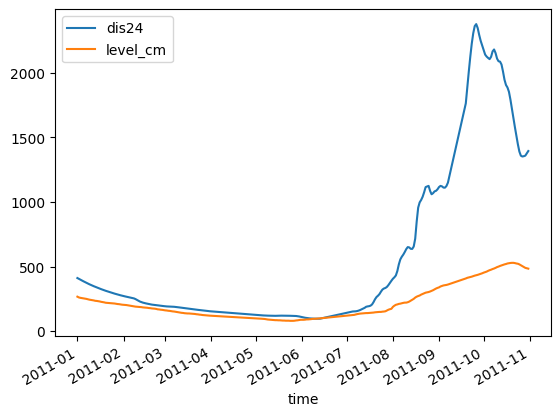

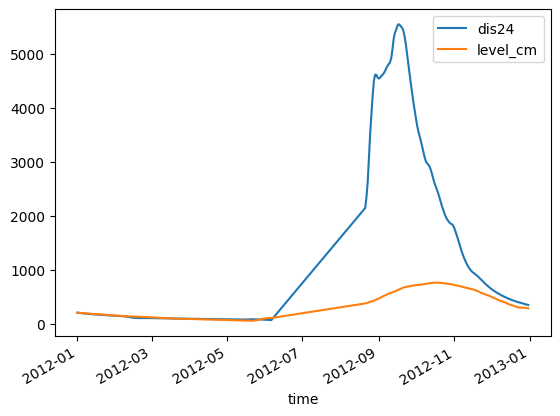

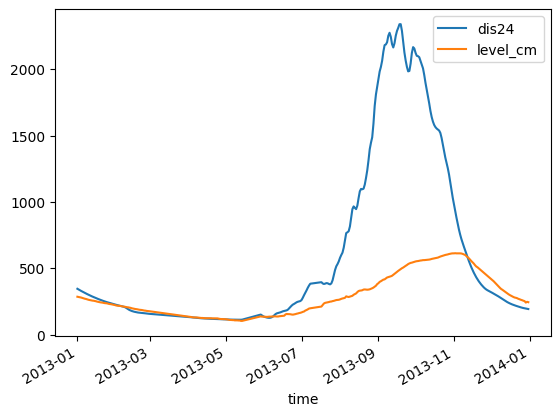

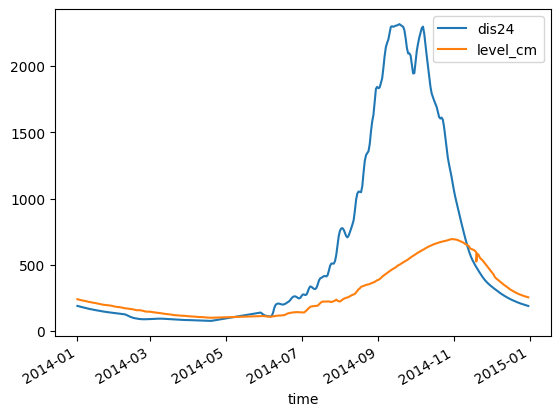

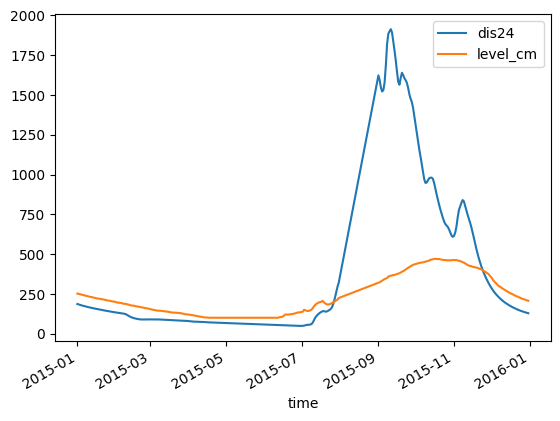

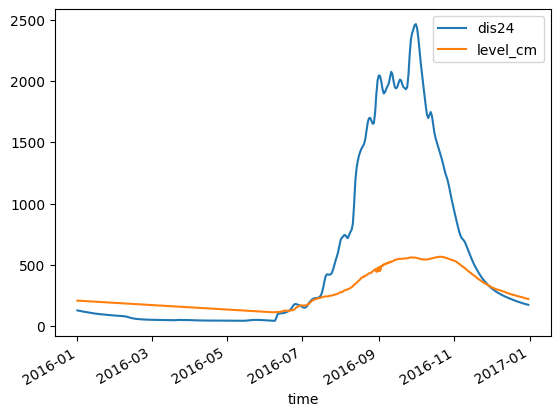

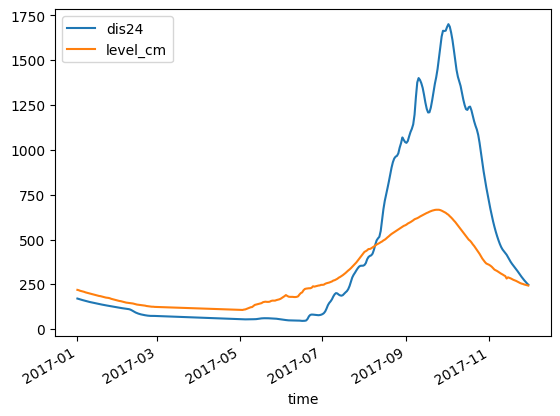

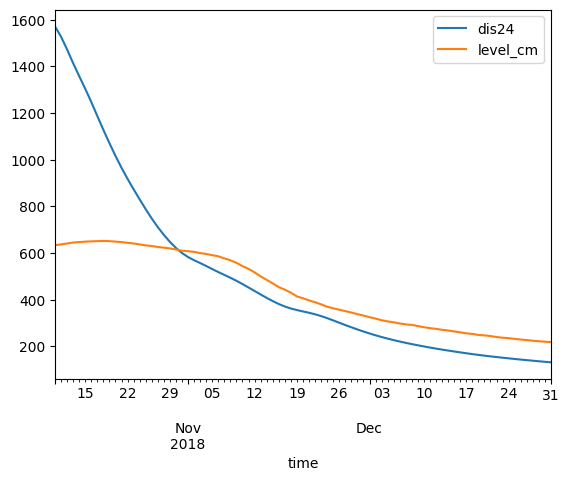

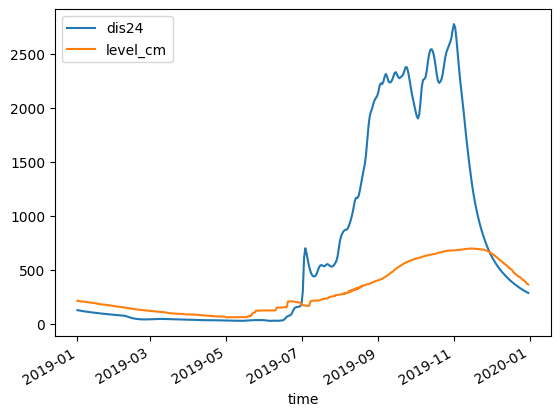

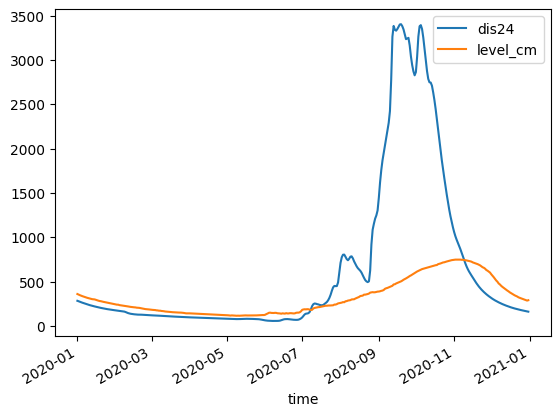

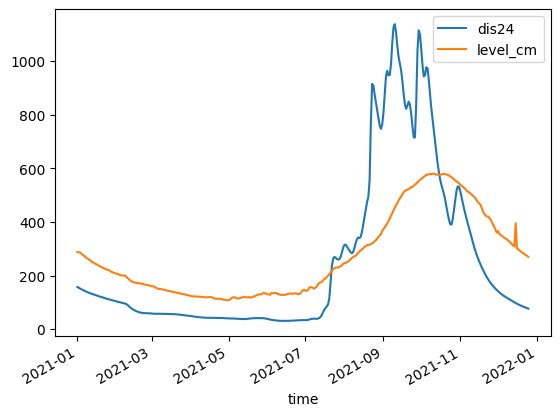

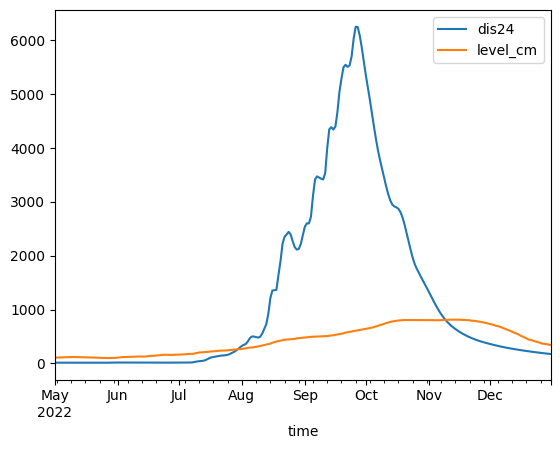

In [234]:
for year in df["time"].dt.year.unique():
    fig, ax = plt.subplots()
    df[df["time"].dt.year == year].set_index("time").plot(
        y=["dis24", "level_cm"], ax=ax
    )
    plt.show()
    plt.close()

In [237]:
df.corr().loc["dis24", "level_cm"]

0.6729637517289515

<Axes: xlabel='level_cm', ylabel='dis24'>

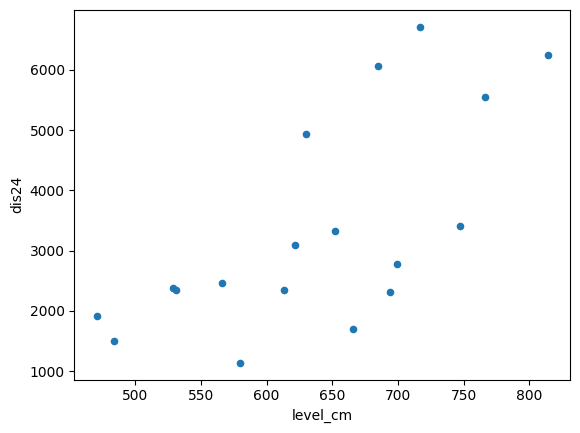

In [235]:
peaks.plot.scatter(x="level_cm", y="dis24")